# PreDist 이벤트 시각화

이 노트북은 `05_데이터셋/PreDist`의 `disturbances.csv`와 raw 센서 zip을 이용해 이벤트 구조를 시각화한다.

확인 항목:
- 연도별 `activity / fault / task` 이벤트 수
- 일자별 이벤트 수
- 2017년 `activity / task` 일자별 분포
- 2014-2020년 1일 단위 raw 센서 window 라벨 분포


In [1]:
from pathlib import Path
from zipfile import ZipFile

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "05_데이터셋" / "PreDist"
ZIP_PATH = DATA_ROOT / "predist_dataset.zip"
METADATA_ROOT = DATA_ROOT / "metadata"

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 30)

assert ZIP_PATH.exists(), ZIP_PATH
assert METADATA_ROOT.exists(), METADATA_ROOT

print("ZIP_PATH:", ZIP_PATH)
print("METADATA_ROOT:", METADATA_ROOT)
print("matplotlib:", plt.matplotlib.__version__)

Matplotlib is building the font cache; this may take a moment.


ZIP_PATH: C:\3rd_Project\HeatGridAgent\05_데이터셋\PreDist\predist_dataset.zip
METADATA_ROOT: C:\3rd_Project\HeatGridAgent\05_데이터셋\PreDist\metadata
matplotlib: 3.11.0


## 1. disturbance 이벤트 로드

`disturbances.csv`는 전체 이벤트 목록이며, 원본 type은 `fault`, `task`, `activity`다.


In [2]:
def load_disturbances(metadata_root: Path) -> pd.DataFrame:
    frames = []
    for mdir in sorted(metadata_root.glob("manufacturer_*")):
        df = pd.read_csv(mdir / "disturbances.csv", sep=";")
        df.insert(0, "manufacturer", mdir.name)
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out["Event start"] = pd.to_datetime(out["Event start"], errors="coerce")
    out["date"] = out["Event start"].dt.date
    out["year"] = out["Event start"].dt.year
    return out

disturbances = load_disturbances(METADATA_ROOT)
print("shape:", disturbances.shape)
display(disturbances.head())
display(disturbances["type"].value_counts().rename_axis("type").reset_index(name="count"))

shape: (328, 6)


,manufacturer,substation ID,Event start,type,date,year
0,manufacturer_1,26,2020-03-10 15:49:00,fault,2020-03-10,2020
1,manufacturer_1,3,2015-11-24 00:00:00,activity,2015-11-24,2015
2,manufacturer_1,3,2015-12-09 13:48:00,fault,2015-12-09,2015
3,manufacturer_1,3,2016-02-29 00:00:00,activity,2016-02-29,2016
4,manufacturer_1,3,2016-10-31 14:18:00,fault,2016-10-31,2016


,type,count
0,fault,155
1,task,90
2,activity,83


## 2. 연도별 이벤트 수


type,year,activity,fault,task,total
0,2013,2,0,0,2
1,2014,8,4,0,12
2,2015,24,11,0,35
3,2016,24,22,0,46
4,2017,25,12,3,40
5,2018,0,12,12,24
6,2019,0,56,49,105
7,2020,0,38,26,64


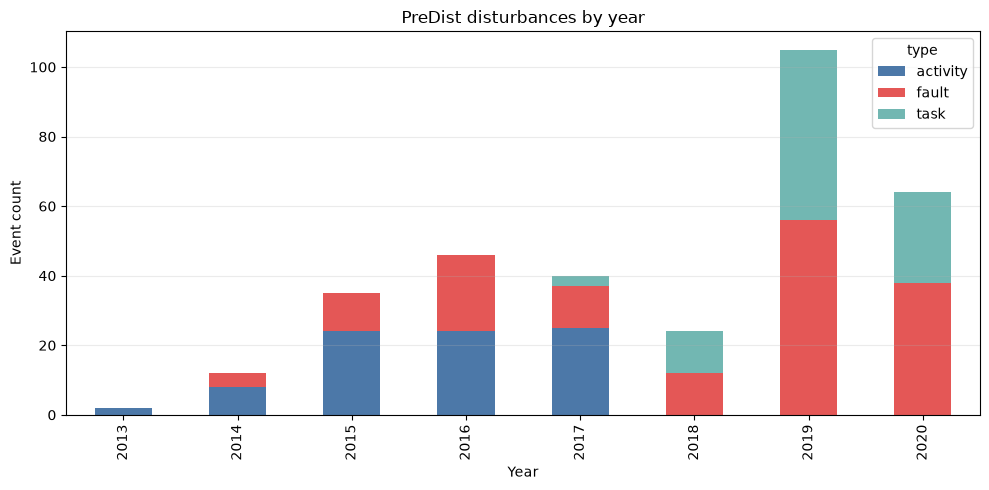

In [3]:
yearly = (
    disturbances.groupby(["year", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["activity", "fault", "task"]:
    if col not in yearly.columns:
        yearly[col] = 0
yearly["total"] = yearly[["activity", "fault", "task"]].sum(axis=1)
yearly = yearly[["year", "activity", "fault", "task", "total"]]
display(yearly)

ax = yearly.set_index("year")[["activity", "fault", "task"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#4C78A8", "#E45756", "#72B7B2"],
)
ax.set_title("PreDist disturbances by year")
ax.set_xlabel("Year")
ax.set_ylabel("Event count")
ax.legend(title="type")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 3. 일자별 이벤트 수

이 DataFrame은 실제 이벤트가 발생한 날짜만 포함한다. 이벤트가 없는 날짜는 행으로 만들지 않았다.


daily shape: (228, 6)


type,year,date,activity,fault,task,total
0,2013,2013-02-19,1,0,0,1
1,2013,2013-08-02,1,0,0,1
2,2014,2014-04-01,1,0,0,1
3,2014,2014-05-02,0,1,0,1
4,2014,2014-05-04,1,1,0,2
5,2014,2014-05-05,1,1,0,2
6,2014,2014-06-23,1,0,0,1
7,2014,2014-07-11,1,0,0,1
8,2014,2014-07-16,1,0,0,1
9,2014,2014-08-27,1,0,0,1


type,year,date,activity,fault,task,total
198,2020,2020-02-04,0,3,1,4
199,2020,2020-02-05,0,0,1,1
200,2020,2020-02-18,0,2,0,2
201,2020,2020-02-19,0,0,2,2
202,2020,2020-02-24,0,1,0,1
203,2020,2020-02-25,0,0,1,1
204,2020,2020-02-26,0,1,0,1
205,2020,2020-02-28,0,1,0,1
206,2020,2020-03-06,0,1,1,2
207,2020,2020-03-07,0,1,0,1


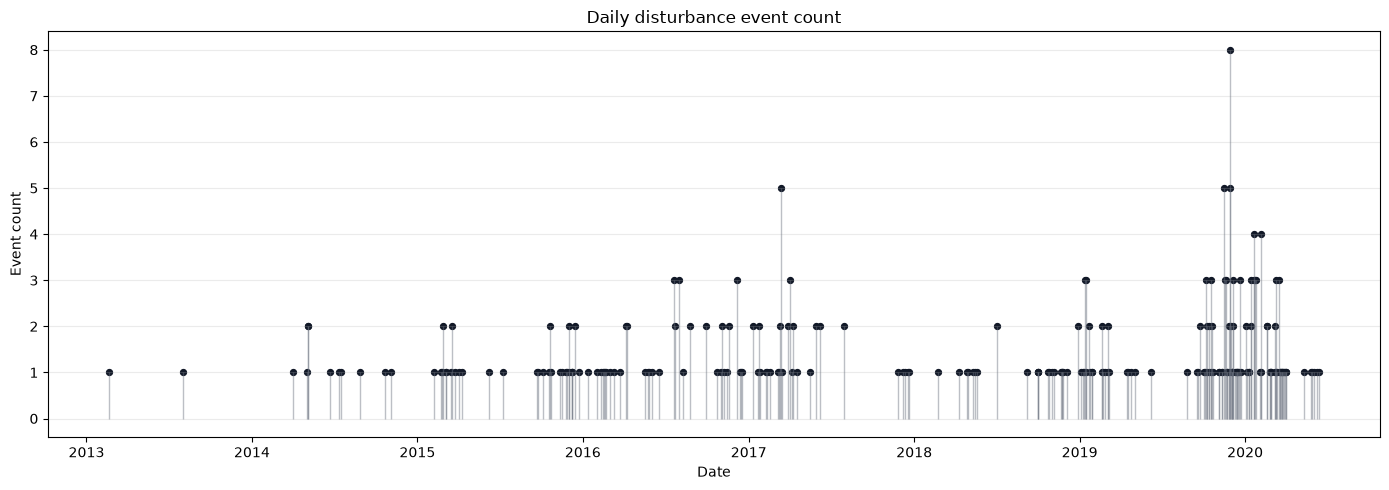

In [4]:
daily = (
    disturbances.groupby(["year", "date", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["activity", "fault", "task"]:
    if col not in daily.columns:
        daily[col] = 0
daily["total"] = daily[["activity", "fault", "task"]].sum(axis=1)
daily = daily[["year", "date", "activity", "fault", "task", "total"]].sort_values(["year", "date"]).reset_index(drop=True)
print("daily shape:", daily.shape)
display(daily.head(30))
display(daily.tail(30))

plot_daily = daily.copy()
plot_daily["date"] = pd.to_datetime(plot_daily["date"])
fig, ax = plt.subplots(figsize=(14, 5))
ax.vlines(plot_daily["date"], 0, plot_daily["total"], color="#6B7280", alpha=0.45, linewidth=1)
ax.scatter(plot_daily["date"], plot_daily["total"], s=18, color="#111827")
ax.set_title("Daily disturbance event count")
ax.set_xlabel("Date")
ax.set_ylabel("Event count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 4. 2017년 activity/task 일자별 분포

2017년의 `activity`는 날짜 단위 기록이 많고, `task`는 7월 이후 소수만 있다.


type,date,activity,task,total
0,2017-01-11,1,0,1
1,2017-01-21,1,0,1
2,2017-01-24,2,0,2
3,2017-01-26,1,0,1
4,2017-02-08,1,0,1
5,2017-02-10,1,0,1
6,2017-02-17,1,0,1
7,2017-03-06,1,0,1
8,2017-03-08,1,0,1
9,2017-03-12,1,0,1


,manufacturer,substation ID,Event start,type
313,manufacturer_2,20,2017-01-11 00:00:00,activity
312,manufacturer_2,9,2017-01-21 00:00:00,activity
127,manufacturer_1,23,2017-01-24 00:00:00,activity
311,manufacturer_2,20,2017-01-24 00:00:00,activity
75,manufacturer_1,15,2017-01-26 00:00:00,activity
310,manufacturer_2,55,2017-02-08 00:00:00,activity
10,manufacturer_1,4,2017-02-10 00:00:00,activity
309,manufacturer_2,40,2017-02-17 00:00:00,activity
308,manufacturer_2,7,2017-03-06 00:00:00,activity
307,manufacturer_2,12,2017-03-08 00:00:00,activity


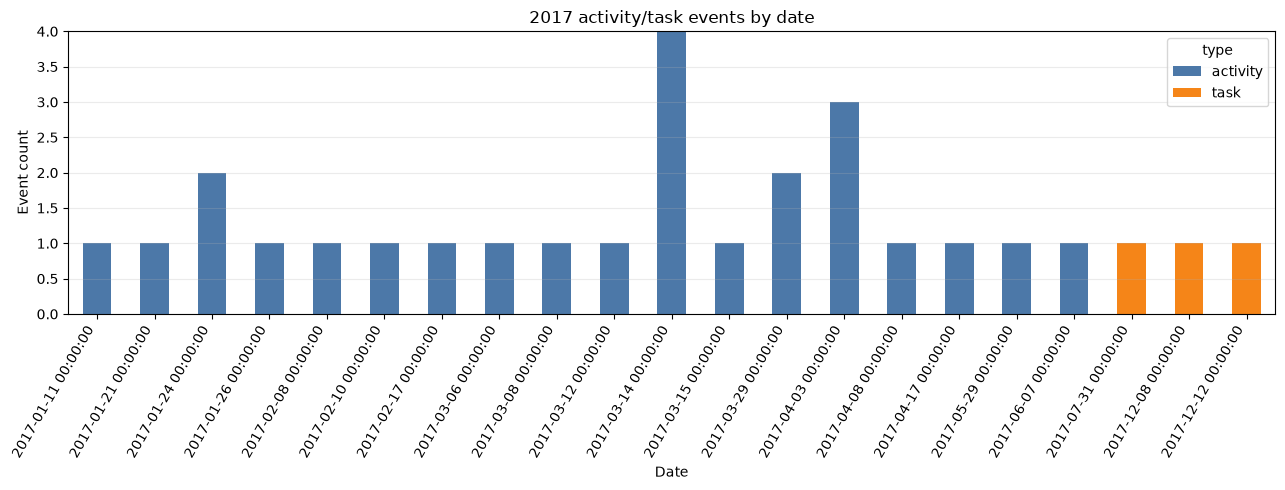

In [5]:
d2017 = disturbances[
    (disturbances["year"] == 2017) & disturbances["type"].isin(["activity", "task"])
].copy()

by_date_2017 = (
    d2017.groupby(["date", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["activity", "task"]:
    if col not in by_date_2017.columns:
        by_date_2017[col] = 0
by_date_2017["total"] = by_date_2017[["activity", "task"]].sum(axis=1)
by_date_2017 = by_date_2017[["date", "activity", "task", "total"]].sort_values("date").reset_index(drop=True)

display(by_date_2017)

detail_2017 = d2017[["manufacturer", "substation ID", "Event start", "type"]].sort_values(["Event start", "manufacturer", "substation ID"])
display(detail_2017)

plot_2017 = by_date_2017.copy()
plot_2017["date"] = pd.to_datetime(plot_2017["date"])
ax = plot_2017.set_index("date")[["activity", "task"]].plot(
    kind="bar",
    stacked=True,
    figsize=(13, 5),
    color=["#4C78A8", "#F58518"],
)
ax.set_title("2017 activity/task events by date")
ax.set_xlabel("Date")
ax.set_ylabel("Event count")
ax.legend(title="type")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 5. activity의 시각 정밀도 확인

`activity`가 정확한 시각 이벤트인지 확인하기 위해 `Event start`의 시간 값을 본다.


In [6]:
activity_events = disturbances[disturbances["type"].eq("activity")].copy()
activity_events["time"] = activity_events["Event start"].dt.time.astype(str)
time_counts = activity_events["time"].value_counts().rename_axis("time").reset_index(name="count")
display(time_counts)
print("activity events:", len(activity_events))
print("all activity at midnight:", bool((activity_events["time"] == "00:00:00").all()))

,time,count
0,00:00:00,83


activity events: 83
all activity at midnight: True


## 6. 2014-2020년 1일 raw 센서 window 라벨 분포

1일 window 하나는 `기계실 1개 x 날짜 1개`다. 따라서 행 수는 달력 일수가 아니라 raw 센서가 존재하는 `substation-day` 수다.

라벨 규칙:
- `none`: 해당 1일 window 안에 이벤트 없음
- `fault`: fault만 있음
- `task`: task만 있음
- `activity`: activity만 있음
- `mixed`: 같은 1일 window 안에 2개 이상 타입이 섞임


In [7]:
START = pd.Timestamp("2014-01-01")
END = pd.Timestamp("2021-01-01")

def build_daily_windows(zip_path: Path, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    records = []
    with ZipFile(zip_path) as z:
        for mdir in ["manufacturer 1", "manufacturer 2"]:
            manufacturer = mdir.replace(" ", "_")
            with z.open(f"{mdir}/disturbances.csv") as f:
                ev = pd.read_csv(f, sep=";")
            ev["Event start"] = pd.to_datetime(ev["Event start"], errors="coerce")
            ev = ev[(ev["Event start"] >= start) & (ev["Event start"] < end)].copy()
            ev["substation ID"] = ev["substation ID"].astype(int)
            files = [
                n for n in z.namelist()
                if n.startswith(f"{mdir}/operational_data/substation_") and n.endswith(".csv")
            ]
            for name in sorted(files):
                sid = int(Path(name).stem.split("_")[-1])
                with z.open(name) as f:
                    ts = pd.read_csv(f, sep=";", usecols=["timestamp"])
                t = pd.to_datetime(ts["timestamp"], errors="coerce").dropna()
                if t.empty:
                    continue
                active_days = t.dt.floor("D").drop_duplicates()
                active_days = active_days[(active_days >= start) & (active_days < end)].sort_values()
                sub_ev = ev[ev["substation ID"].eq(sid)].copy()
                for day in active_days:
                    nxt = day + pd.Timedelta(days=1)
                    ebin = sub_ev[(sub_ev["Event start"] >= day) & (sub_ev["Event start"] < nxt)]
                    types = sorted(ebin["type"].dropna().unique().tolist())
                    if not types:
                        label = "none"
                    elif len(types) == 1:
                        label = types[0]
                    else:
                        label = "mixed"
                    records.append({
                        "manufacturer": manufacturer,
                        "substation_id": sid,
                        "date": day.date(),
                        "year": day.year,
                        "event_count": len(ebin),
                        "label": label,
                        "has_event": int(len(ebin) > 0),
                        "has_fault": int("fault" in types),
                        "has_task": int("task" in types),
                        "has_activity": int("activity" in types),
                    })
    return pd.DataFrame(records)

daily_windows = build_daily_windows(ZIP_PATH, START, END)
print("daily_windows shape:", daily_windows.shape)
display(daily_windows.head())

label_counts = daily_windows["label"].value_counts().rename_axis("label").reset_index(name="count")
display(label_counts)

by_year_window = daily_windows.groupby("year").agg(
    total_windows=("has_event", "size"),
    event_windows=("has_event", "sum"),
)
by_year_window["none_windows"] = by_year_window["total_windows"] - by_year_window["event_windows"]
by_year_window["event_rate"] = by_year_window["event_windows"] / by_year_window["total_windows"]
display(by_year_window.reset_index())

daily_windows shape: (82556, 10)


,manufacturer,substation_id,date,year,event_count,label,has_event,has_fault,has_task,has_activity
0,manufacturer_1,1,2018-06-10,2018,0,none,0,0,0,0
1,manufacturer_1,1,2018-06-11,2018,0,none,0,0,0,0
2,manufacturer_1,1,2018-06-12,2018,0,none,0,0,0,0
3,manufacturer_1,1,2018-06-13,2018,0,none,0,0,0,0
4,manufacturer_1,1,2018-06-14,2018,0,none,0,0,0,0


,label,count
0,none,82303
1,fault,95
2,task,61
3,activity,60
4,mixed,37


,year,total_windows,event_windows,none_windows,event_rate
0,2014,1724,8,1716,0.004640
1,2015,5814,32,5782,0.005504
2,2016,13046,38,13008,0.002913
3,2017,14796,33,14763,0.002230
4,2018,15959,20,15939,0.001253
5,2019,19317,70,19247,0.003624
6,2020,11900,52,11848,0.004370


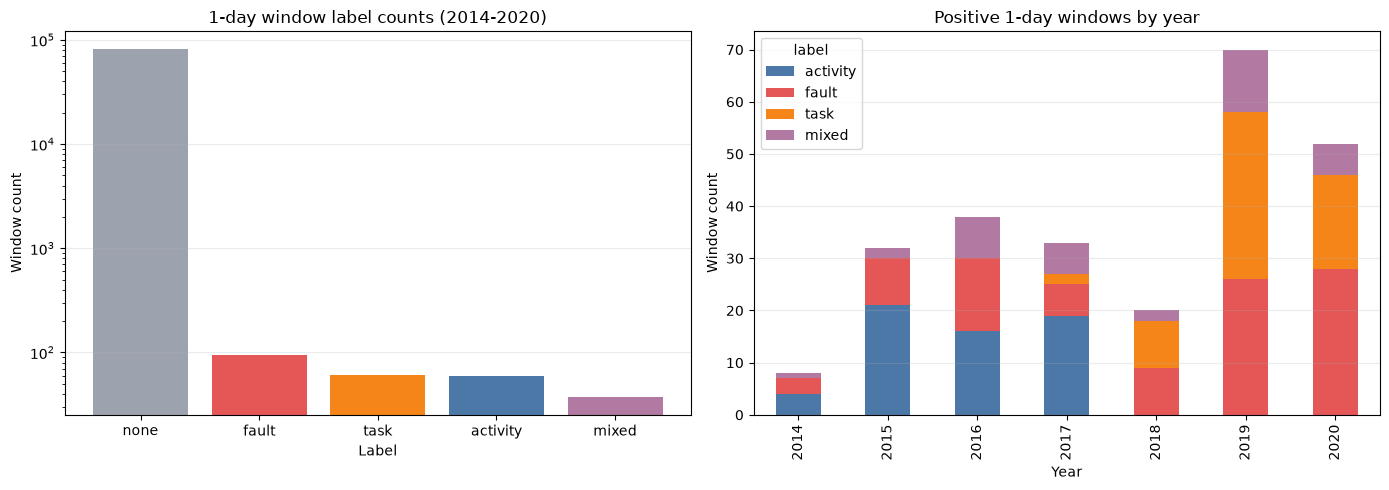

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_counts = label_counts.set_index("label").loc[["none", "fault", "task", "activity", "mixed"]]
axes[0].bar(plot_counts.index, plot_counts["count"], color=["#9CA3AF", "#E45756", "#F58518", "#4C78A8", "#B279A2"])
axes[0].set_title("1-day window label counts (2014-2020)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Window count")
axes[0].set_yscale("log")
axes[0].grid(axis="y", alpha=0.25)

positive_by_year = (
    daily_windows[daily_windows["has_event"].eq(1)]
    .groupby(["year", "label"])
    .size()
    .unstack(fill_value=0)
)
for col in ["fault", "task", "activity", "mixed"]:
    if col not in positive_by_year.columns:
        positive_by_year[col] = 0
positive_by_year = positive_by_year[["activity", "fault", "task", "mixed"]]
positive_by_year.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#4C78A8", "#E45756", "#F58518", "#B279A2"],
)
axes[1].set_title("Positive 1-day windows by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Window count")
axes[1].legend(title="label")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 7. 요약

- `activity`는 원본상 `task`와 다르지만, 날짜 단위 활동 기록으로 보인다.
- `activity`는 전부 `00:00:00`으로 기록되어 있어 정확한 시각 이벤트로 보기보다 1일 단위 label로 붙이는 편이 안전하다.
- 1일 window는 `기계실 x 날짜` 단위이므로 2014-2020 기간에 82,556개가 생성된다.
- event window는 매우 적어 클래스 불균형이 크므로 학습 시 `none` downsampling이 필요하다.
